## Business Problem Statement



The goal of this analysis is to understand sales and product performance trends in the UK e-commerce dataset spanning December 2010 to December 2011. Using transactional data at the invoice and product level, we aim to generate actionable insights that inform sales strategies, inventory planning, and product optimization.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
%matplotlib inline
import warnings 
warnings.filterwarnings('ignore')
pd.options.display.float_format = '{:,.2f}'.format

In [7]:
data_frame = pd.read_parquet('D:\Data\projects\Market & Product Performance Review\data_set\Ecommerce.parquet'  )

data_frame

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,"17,850.00",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,"17,850.00",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,"17,850.00",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,"17,850.00",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,"17,850.00",United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,"12,680.00",France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,"12,680.00",France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,"12,680.00",France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,"12,680.00",France


In [8]:
data_frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [9]:
data = data_frame.copy()

## Clenaing the data


In [10]:
data.columns = ['Invoice_No', 'Stock_Code', 'Description', 'Quantity', 'Invoice_Date','Unit_Price', 'Customer_ID', 'Country']
data.columns = data.columns.str.lower()


In [11]:
data['ivoice_data'] = pd.to_datetime(data['invoice_date'])
data['customer_id'] = data['customer_id'].astype('object')

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   invoice_no    541909 non-null  object        
 1   stock_code    541909 non-null  object        
 2   description   540455 non-null  object        
 3   quantity      541909 non-null  int64         
 4   invoice_date  541909 non-null  object        
 5   unit_price    541909 non-null  float64       
 6   customer_id   406829 non-null  object        
 7   country       541909 non-null  object        
 8   ivoice_data   541909 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(1), object(6)
memory usage: 37.2+ MB


In [13]:
data.describe().round(0)

,quantity,unit_price,ivoice_data
count,"541,909.00","541,909.00",541909
mean,10.00,5.00,2011-07-04 13:34:57.156386048
min,"-80,995.00","-11,062.00",2010-12-01 08:26:00
25%,1.00,1.00,2011-03-28 11:34:00
50%,3.00,2.00,2011-07-19 17:17:00
75%,10.00,4.00,2011-10-19 11:27:00
max,"80,995.00","38,970.00",2011-12-09 12:50:00
std,218.00,97.00,NaN


In [14]:
data.describe(include= 'object')

,invoice_no,stock_code,description,invoice_date,customer_id,country
count,541909,541909,540455,541909,"406,829.00",541909
unique,25900,4070,4223,23260,"4,372.00",38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,10/31/2011 14:41,"17,841.00",United Kingdom
freq,1114,2313,2369,1114,"7,983.00",495478


In [15]:
data.isnull().sum()

invoice_no           0
stock_code           0
description       1454
quantity             0
invoice_date         0
unit_price           0
customer_id     135080
country              0
ivoice_data          0
dtype: int64

In [16]:
data.duplicated().sum()

5268

In [17]:
data = data.drop_duplicates()

In [18]:
data.duplicated().sum()

0

In [19]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 536641 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   invoice_no    536641 non-null  object        
 1   stock_code    536641 non-null  object        
 2   description   535187 non-null  object        
 3   quantity      536641 non-null  int64         
 4   invoice_date  536641 non-null  object        
 5   unit_price    536641 non-null  float64       
 6   customer_id   401604 non-null  object        
 7   country       536641 non-null  object        
 8   ivoice_data   536641 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(1), object(6)
memory usage: 40.9+ MB


In [20]:

only_digit = data['stock_code'].str.match(r'^[A-Za-z\d]+$')

only_one_digit = data['stock_code'].str.count(r'\d') <=1

#data[~( data['stock_code'].str.match(r'^[A-Za-z\d]+$'))]
#data[( data['stock_code'].str.count(r'\d') <=1)]

result = data[(only_one_digit) & (only_digit)]
result['stock_code'].unique()

array(['POST', 'D', 'C2', 'DOT', 'M', 'S', 'AMAZONFEE', 'm', 'DCGSSBOY',
       'DCGSSGIRL', 'PADS', 'B', 'CRUK'], dtype=object)

In [21]:
resukt = result[['stock_code' , 'description']].drop_duplicates()

In [22]:
print(result['description'].to_list())
print(result['stock_code'].to_list())

['POSTAGE', 'Discount', 'POSTAGE', 'POSTAGE', 'CARRIAGE', 'DOTCOM POSTAGE', 'Manual', 'Manual', 'DOTCOM POSTAGE', 'POSTAGE', 'POSTAGE', 'POSTAGE', 'POSTAGE', 'DOTCOM POSTAGE', 'DOTCOM POSTAGE', 'Manual', 'DOTCOM POSTAGE', 'DOTCOM POSTAGE', 'POSTAGE', 'POSTAGE', 'Manual', 'POSTAGE', 'POSTAGE', 'POSTAGE', 'POSTAGE', 'POSTAGE', 'Manual', 'Manual', 'Manual', 'Manual', 'Discount', 'POSTAGE', 'POSTAGE', 'Manual', 'POSTAGE', 'Manual', 'POSTAGE', 'Manual', 'DOTCOM POSTAGE', 'DOTCOM POSTAGE', 'POSTAGE', 'POSTAGE', 'CARRIAGE', 'Manual', 'CARRIAGE', 'Manual', 'Manual', 'POSTAGE', 'DOTCOM POSTAGE', 'Manual', 'POSTAGE', 'POSTAGE', 'Manual', 'SAMPLES', 'SAMPLES', 'POSTAGE', 'Discount', 'AMAZON FEE', 'Manual', 'Manual', 'AMAZON FEE', 'AMAZON FEE', 'DOTCOM POSTAGE', 'DOTCOM POSTAGE', 'DOTCOM POSTAGE', 'DOTCOM POSTAGE', 'DOTCOM POSTAGE', 'AMAZON FEE', 'AMAZON FEE', 'AMAZON FEE', 'AMAZON FEE', 'DOTCOM POSTAGE', 'POSTAGE', 'POSTAGE', 'Manual', 'Manual', 'Manual', 'POSTAGE', 'DOTCOM POSTAGE', 'Discount', 

In [23]:
#n_products = ['C2', 'POST', 'DOT', 'M', 'm', 'S', 'AMAZONFEE', 'B']

In [24]:
non_product = ['AMAZONFEE', 'B', 'C2',  'DOT', 'M', 'POST', 'S', 'm']
non_product_desc = ['AMAZON FEE', 'Adjust bad debt', 'CARRIAGE', np.nan,  'DOTCOM POSTAGE',  'POSTAGE', 'SAMPLES', 'Manual']


In [25]:
data =data[(~data['stock_code'].isin(non_product)) &  (~data['description'].isin(non_product_desc))].reset_index()

In [26]:
data['Month'] = data['ivoice_data'].dt.to_period('M').dt.to_timestamp()
data['total_sale'] =round( data['quantity'] * data['unit_price'] , 2)
data['is_return'] = data['quantity'] < 0

data_clean = data[(data['quantity'] > 0) & (data['unit_price'] >0)]

In [27]:
data_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 522583 entries, 0 to 533864
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   index         522583 non-null  int64         
 1   invoice_no    522583 non-null  object        
 2   stock_code    522583 non-null  object        
 3   description   522583 non-null  object        
 4   quantity      522583 non-null  int64         
 5   invoice_date  522583 non-null  object        
 6   unit_price    522583 non-null  float64       
 7   customer_id   391165 non-null  object        
 8   country       522583 non-null  object        
 9   ivoice_data   522583 non-null  datetime64[ns]
 10  Month         522583 non-null  datetime64[ns]
 11  total_sale    522583 non-null  float64       
 12  is_return     522583 non-null  bool          
dtypes: bool(1), datetime64[ns](2), float64(2), int64(2), object(6)
memory usage: 52.3+ MB


In [28]:
data_clean[['invoice_no' , 'stock_code', 'ivoice_data']].duplicated().sum()

5242

In [29]:
data_clean_group = data_clean.groupby(['invoice_no', 'stock_code'] ,as_index= False ).agg(
    quantity = ('quantity' ,'sum'),
    total_sale = ('total_sale' ,'sum'),
    unit_price = ('unit_price' , 'first'),
    description = ('description' , 'first'),
    invoice_date = ('invoice_date' , 'first'),
    customer_id = ('customer_id'  ,'first'),
    country = ('country' , 'first')
)
data_clean_group

,invoice_no,stock_code,quantity,total_sale,unit_price,description,invoice_date,customer_id,country
0,536365,21730,6,25.50,4.25,GLASS STAR FROSTED T-LIGHT HOLDER,12/1/2010 8:26,"17,850.00",United Kingdom
1,536365,22752,2,15.30,7.65,SET 7 BABUSHKA NESTING BOXES,12/1/2010 8:26,"17,850.00",United Kingdom
2,536365,71053,6,20.34,3.39,WHITE METAL LANTERN,12/1/2010 8:26,"17,850.00",United Kingdom
3,536365,84029E,6,20.34,3.39,RED WOOLLY HOTTIE WHITE HEART.,12/1/2010 8:26,"17,850.00",United Kingdom
4,536365,84029G,6,20.34,3.39,KNITTED UNION FLAG HOT WATER BOTTLE,12/1/2010 8:26,"17,850.00",United Kingdom
...,...,...,...,...,...,...,...,...,...
517329,581587,22730,4,15.00,3.75,ALARM CLOCK BAKELIKE IVORY,12/9/2011 12:50,"12,680.00",France
517330,581587,22899,6,12.60,2.10,CHILDREN'S APRON DOLLY GIRL,12/9/2011 12:50,"12,680.00",France
517331,581587,23254,4,16.60,4.15,CHILDRENS CUTLERY DOLLY GIRL,12/9/2011 12:50,"12,680.00",France
517332,581587,23255,4,16.60,4.15,CHILDRENS CUTLERY CIRCUS PARADE,12/9/2011 12:50,"12,680.00",France


In [30]:
data_clean_group[['stock_code', 'invoice_date' , 'invoice_no']].duplicated().sum()

0

In [31]:
data_clean_group.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517334 entries, 0 to 517333
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   invoice_no    517334 non-null  object 
 1   stock_code    517334 non-null  object 
 2   quantity      517334 non-null  int64  
 3   total_sale    517334 non-null  float64
 4   unit_price    517334 non-null  float64
 5   description   517334 non-null  object 
 6   invoice_date  517334 non-null  object 
 7   customer_id   386340 non-null  object 
 8   country       517334 non-null  object 
dtypes: float64(2), int64(1), object(6)
memory usage: 35.5+ MB


In [32]:
data_clean_group['invoice_date']  = pd.to_datetime(data_clean_group['invoice_date'] )
data_clean_group['month'] = data_clean_group['invoice_date'].dt.to_period("M").dt.to_timestamp().dt.strftime('%Y/%m/%d')

In [33]:
print(data_clean_group['invoice_date'].min())
print(data_clean_group['invoice_date'].max())

2010-12-01 08:26:00
2011-12-09 12:50:00


In [34]:
data_clean_group[data_clean_group['quantity'] > 10000]

,invoice_no,stock_code,quantity,total_sale,unit_price,description,invoice_date,customer_id,country,month
58853,541431,23166,74215,"77,183.60",1.04,MEDIUM CERAMIC TOP STORAGE JAR,2011-01-18 10:01:00,"12,346.00",United Kingdom,2011/01/01
515879,581483,23843,80995,"168,469.60",2.08,"PAPER CRAFT , LITTLE BIRDIE",2011-12-09 09:15:00,"16,446.00",United Kingdom,2011/12/01


In [35]:
data_clean_group[data_clean_group['unit_price'] > 500]

,invoice_no,stock_code,quantity,total_sale,unit_price,description,invoice_date,customer_id,country,month
212745,556444,22502,60,"38,970.00",649.50,PICNIC BASKET WICKER 60 PIECES,2011-06-10 15:28:00,"15,098.00",United Kingdom,2011/06/01
212746,556446,22502,1,649.50,649.50,PICNIC BASKET WICKER 60 PIECES,2011-06-10 15:33:00,"15,098.00",United Kingdom,2011/06/01


In [36]:
q0_price_quantial = data_clean_group['unit_price'].quantile(q=0.01)
q1_price_quantial = data_clean_group['unit_price'].quantile(q=0.99)
data_clean_group['unit_price_wi'] = data_clean_group['unit_price'].clip( lower = q0_price_quantial, upper = q1_price_quantial)

q0_quantity_quantial = data_clean_group['quantity'].quantile(q=0.01)
q1_quantity_quantial = data_clean_group['quantity'].quantile(q=0.99)
data_clean_group['quantity_wi'] = data_clean_group['quantity'].clip( lower = q0_quantity_quantial, upper = q1_quantity_quantial)

data_clean_group['total_sale_wi'] = round(data_clean_group['quantity'] * data_clean_group['unit_price'])

In [37]:
data_clean_group[data_clean_group['quantity_wi'] > 10000]

,invoice_no,stock_code,quantity,total_sale,unit_price,description,invoice_date,customer_id,country,month,unit_price_wi,quantity_wi,total_sale_wi


In [38]:
data_clean_group[data_clean_group['unit_price_wi'] > 500]

,invoice_no,stock_code,quantity,total_sale,unit_price,description,invoice_date,customer_id,country,month,unit_price_wi,quantity_wi,total_sale_wi


In [39]:
data_raw_analysis = data_clean_group[['invoice_no', 'stock_code', 'quantity', 'total_sale', 'unit_price','description', 'invoice_date', 'month', 'customer_id', 'country']]
data_clean_analysis = data_clean_group[['invoice_no', 'stock_code', 'description', 'invoice_date','month',  'customer_id', 'country', 'unit_price_wi', 'quantity_wi', 'total_sale_wi']]

In [40]:
data_raw_analysis['day_name'] = data_raw_analysis['invoice_date'].dt.day_name()
data_raw_analysis['hour'] = data_raw_analysis['invoice_date'].dt.hour

## Analysis


####Overall Sales Trends

Q1. Which months generated the highest total sales revenue during the observation period

In [41]:
revenue_per_month =( 
    data_raw_analysis
    .groupby('month')['total_sale']
    .sum()
    #.sort_values(ascending=False)
    )

revenue_per_month

month
2010/12/01     775,729.95
2011/01/01     670,454.46
2011/02/01     507,866.54
2011/03/01     689,841.84
2011/04/01     515,484.66
2011/05/01     740,051.33
2011/06/01     737,683.99
2011/07/01     688,252.67
2011/08/01     724,308.16
2011/09/01   1,028,375.38
2011/10/01   1,103,360.92
2011/11/01   1,452,145.98
2011/12/01     614,514.25
Name: total_sale, dtype: float64

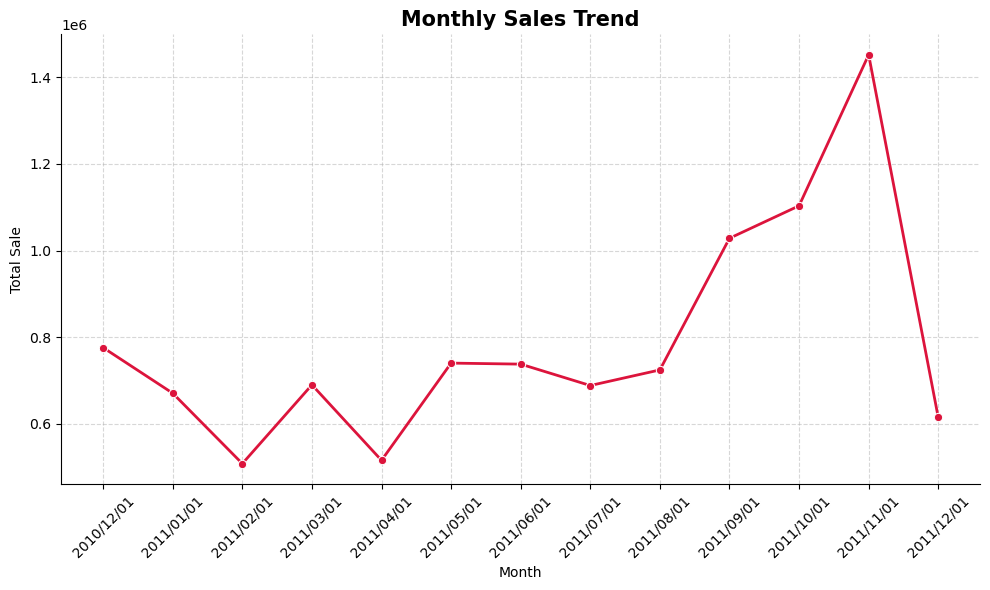

In [42]:
plt.figure(figsize=(10,6))

sns.lineplot(
    x=revenue_per_month.index,
    y=revenue_per_month.values,
    marker='o',
    linewidth=2,
    color='crimson'
)

plt.title("Monthly Sales Trend", fontsize=15, weight="bold")
plt.xlabel("Month")
plt.ylabel("Total Sale")
plt.grid(True, linestyle='--', alpha=0.5)

plt.xticks(rotation=45)
sns.despine()
plt.tight_layout()
plt.show()

Month number 11 had the highest sales, which is related to the Christmas season. It is followed consecutively by months 9 and 10, with a clear difference compared to the other months. The months with the lowest sales are months 2 and 4, while the rest are in the middle range.

Q2. Which months recorded the highest number of customer orders

In [43]:
order_per_month = (
    data_raw_analysis
    .groupby('month')['invoice_no']
    .nunique()
    #.sort_values(ascending=False)
    )
order_per_month

month
2010/12/01    1551
2011/01/01    1082
2011/02/01    1093
2011/03/01    1440
2011/04/01    1236
2011/05/01    1669
2011/06/01    1525
2011/07/01    1452
2011/08/01    1339
2011/09/01    1820
2011/10/01    2007
2011/11/01    2753
2011/12/01     817
Name: invoice_no, dtype: int64

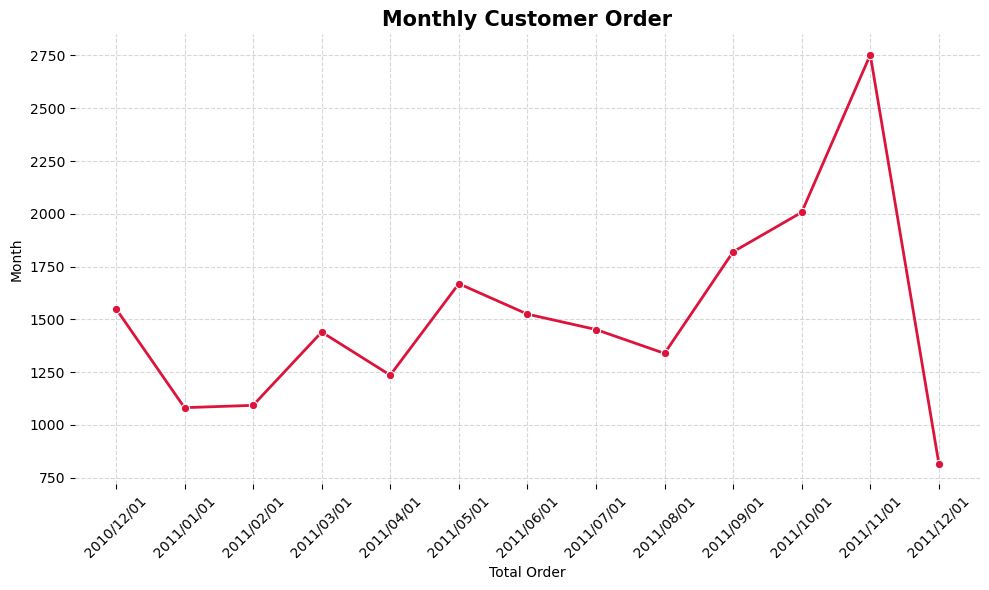

In [44]:
plt.figure(figsize=(10,6))


colors = sns.color_palette("rocket", len(order_per_month))

sns.lineplot(
    x=order_per_month.index,
    y=order_per_month.values,
        marker='o',
    linewidth=2,
    color='crimson'
)

plt.title("Monthly Customer Order", fontsize=15, weight="bold")
plt.xlabel("Total Order")
plt.ylabel("Month")

plt.grid(True, linestyle='--', alpha=0.5)

plt.xticks(rotation=45)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

Month 11 had the highest number of orders, which explains why it is the best-selling month. It is followed by months 10 and 9, which are also among the top-selling months. As for month 1, it appears lower because we only have sales data for 9 days of the month, so this is expected.

Regarding the months with the lowest number of orders, month 1 appears here, even though it was not actually the lowest-selling month. This is because it had a small number of orders, but the order sales amounts were relatively high.

َQ3 How did Average Order Value evolve across months?

In [45]:
avg_order_value_over_month= (
    round(revenue_per_month / order_per_month ,1)
    #.sort_values(ascending=False)
    )
avg_order_value_over_month

month
2010/12/01   500.10
2011/01/01   619.60
2011/02/01   464.70
2011/03/01   479.10
2011/04/01   417.10
2011/05/01   443.40
2011/06/01   483.70
2011/07/01   474.00
2011/08/01   540.90
2011/09/01   565.00
2011/10/01   549.80
2011/11/01   527.50
2011/12/01   752.20
dtype: float64

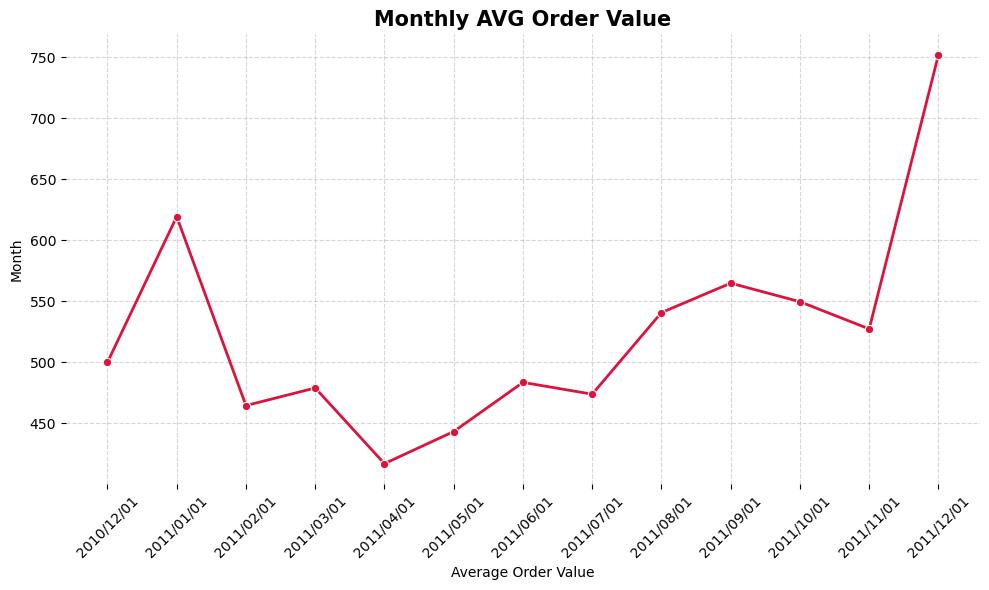

In [46]:
plt.figure(figsize=(10,6))


colors = sns.color_palette("rocket", len(avg_order_value_over_month))

sns.lineplot(
    x=avg_order_value_over_month.index,
    y=avg_order_value_over_month.values,
        marker='o',
    linewidth=2,
    color='crimson'
)

plt.title("Monthly AVG Order Value", fontsize=15, weight="bold")
plt.xlabel("Average Order Value")
plt.ylabel("Month")


plt.grid(True, linestyle='--', alpha=0.5)

plt.xticks(rotation=45)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

At the top, we have month 12, which is mostly due to limited data; however, the order value appears high. Here, we notice that month 1 had a small number of orders but generated large sales, which is reflected in the results. Similarly, month 4 is at the bottom, indicating that it is a weak month both in terms of orders and sales. The remaining months fall in the middle range with moderate values.

Which day records the lowest sales performance?

In [47]:
def time_period(hour):
    if 5 <= hour < 9:
        return "Early Morning"
    elif 9 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 21:
        return "Evening"
    else:
        return "Night"


data_raw_analysis['time_period'] = data_raw_analysis['hour'].apply(time_period)

In [48]:

data_raw_analysis['time_period'].value_counts()

time_period
Afternoon        334384
Morning          134972
Evening           38871
Early Morning      9107
Name: count, dtype: int64

In [49]:
sales_by_day = (
    data_raw_analysis
    .groupby('day_name')['total_sale']
    .sum()
)
sales_by_day

day_name
Friday      1,767,252.27
Monday      1,683,079.56
Sunday        798,311.50
Thursday    2,131,785.60
Tuesday     2,085,145.32
Wednesday   1,782,495.88
Name: total_sale, dtype: float64

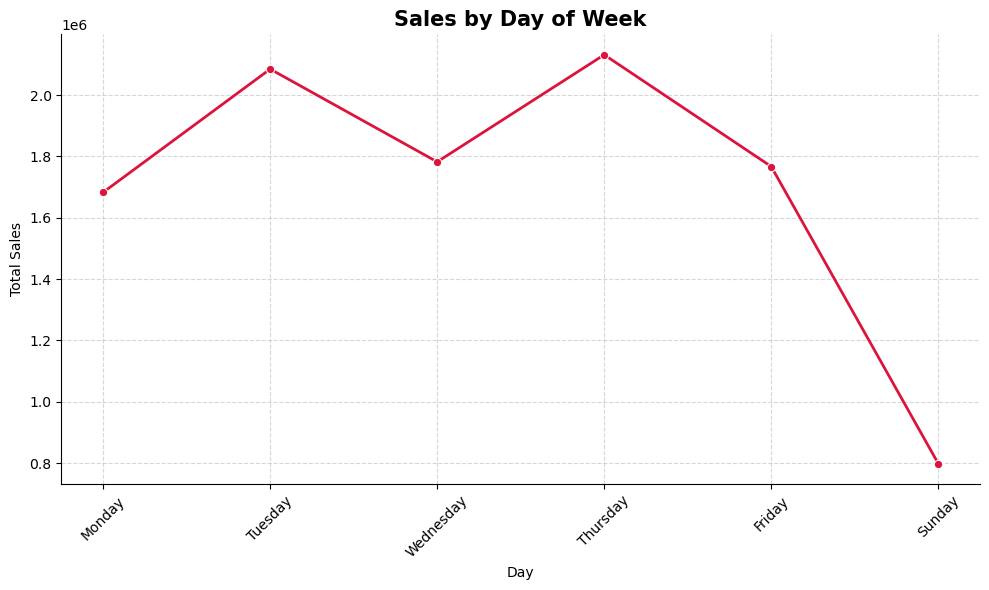

In [50]:
days_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Sunday']

sales_by_day.index = pd.Categorical(sales_by_day.index, categories=days_order, ordered=True)
sales_by_day = sales_by_day.sort_index()  # ترتيب حسب الأسبوع

plt.figure(figsize=(10,6))

sns.lineplot(
    x=sales_by_day.index,
    y=sales_by_day.values,
    marker='o',
    linewidth=2,
    color='crimson'
)

plt.title("Sales by Day of Week", fontsize=15, weight="bold")
plt.xlabel("Day")
plt.ylabel("Total Sales")
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
sns.despine()
plt.tight_layout()
plt.show()

Thursday and Tuesday recorded the highest sales, each exceeding 2 million in Sales, while the remaining days were relatively close to each other at around 1.6 million.
Sunday shows a significant drop, falling below 800,000, most likely because it is a holiday/non-working day.

During which time period does the business generate the highest sales?

In [51]:
sales_by_time_period = (
    data_raw_analysis
    .groupby('time_period')['total_sale']
    .sum()
)

In [52]:
order = ["Early Morning", "Morning", "Afternoon", "Evening", "Night"]

sales_by_time_period = sales_by_time_period.reindex(order)

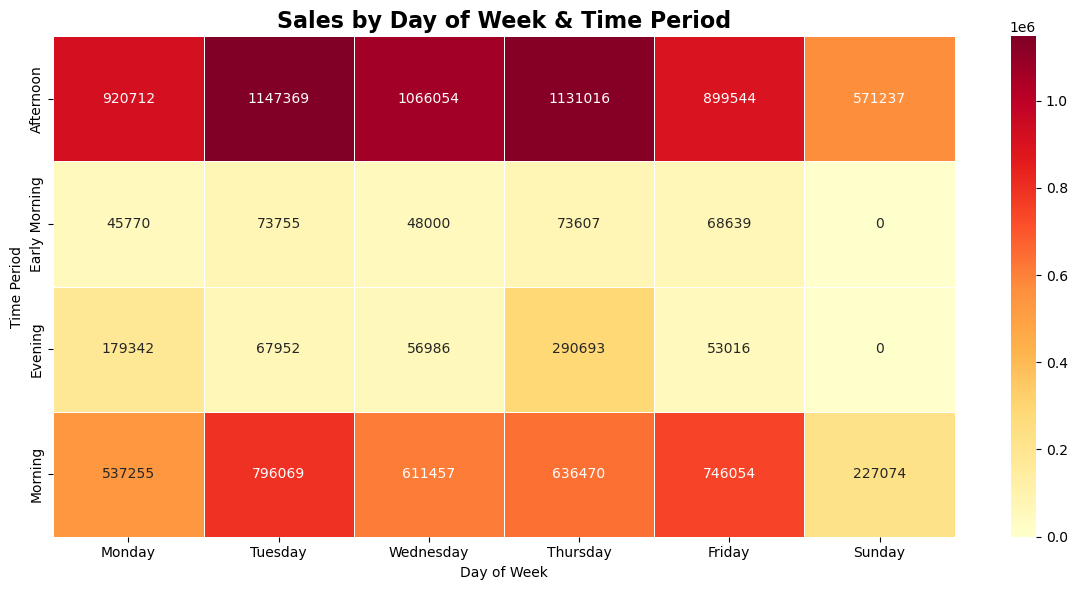

In [53]:
sales_by_day_time = (
    data_raw_analysis
    .groupby(['day_name', 'time_period'])['total_sale']
    .sum()
    .reset_index()
)
time_order  = ["Early Morning", "Morning", "Afternoon", "Evening", "Night"]

sales_by_day_time['day_name'] = pd.Categorical(sales_by_day_time['day_name'], categories=days_order, ordered=True)
sales_by_day_time['time_period'] = pd.Categorical(sales_by_day_time['time_period'], categories=time_order, ordered=True)

pivot_table = sales_by_day_time.pivot(index='time_period', columns='day_name', values='total_sale').fillna(0)

plt.figure(figsize=(12,6))
sns.heatmap(pivot_table, cmap="YlOrRd", annot=True, fmt=".0f", linewidths=0.5)

plt.title("Sales by Day of Week & Time Period", fontsize=16, weight="bold")
plt.xlabel("Day of Week")
plt.ylabel("Time Period")

plt.tight_layout()
plt.show()

The Afternoon period accounts for the largest share of sales across all days without exception, with Thursday and Tuesday clearly dominating this time window, followed by the Morning period.
The Early Morning period records the lowest sales overall, while Sunday shows the weakest performance across all time periods.
It is also noticeable that during the Evening period, Thursday and Monday stand out with a clear difference compared to the rest of the days

Q4. How did total sales change month-over-month throughout the month period?

In [54]:
MOM_change = revenue_per_month.reset_index()
MOM_change['orders'] = order_per_month.values
MOM_change['AOV'] = avg_order_value_over_month.values
MOM_change['MoM_Sales'] = (MOM_change['total_sale'].diff() / MOM_change['total_sale'].shift(1) *100).round(1)
MOM_change['MoM_orders'] = (MOM_change['orders'].diff() / MOM_change['orders'].shift(1) *100).round(1)
MOM_change['MoM_AOV'] =(MOM_change['AOV'].diff() / MOM_change['AOV'].shift(1) *100).round(1)

MOM_change.fillna('-')

,month,total_sale,orders,AOV,MoM_Sales,MoM_orders,MoM_AOV
0,2010/12/01,"775,729.95",1551,500.10,-,-,-
1,2011/01/01,"670,454.46",1082,619.60,-13.60,-30.20,23.90
2,2011/02/01,"507,866.54",1093,464.70,-24.30,1.00,-25.00
3,2011/03/01,"689,841.84",1440,479.10,35.80,31.70,3.10
4,2011/04/01,"515,484.66",1236,417.10,-25.30,-14.20,-12.90
5,2011/05/01,"740,051.33",1669,443.40,43.60,35.00,6.30
6,2011/06/01,"737,683.99",1525,483.70,-0.30,-8.60,9.10
7,2011/07/01,"688,252.67",1452,474.00,-6.70,-4.80,-2.00
8,2011/08/01,"724,308.16",1339,540.90,5.20,-7.80,14.10
9,2011/09/01,"1,028,375.38",1820,565.00,42.00,35.90,4.50


In [55]:
def highlight_change(val):
    if pd.isna(val):
        return ''  
    color = 'green' if val > 0 else 'red'
    return f'color: {color}'

MOM_change.style.applymap(
    highlight_change,
    subset=['MoM_Sales', 'MoM_orders', 'MoM_AOV']
).format({
    'MoM_Sales': lambda x: '-' if pd.isna(x) else f"{x:+.1f}%",
    'MoM_orders': lambda x: '-' if pd.isna(x) else f"{x:+.1f}%",
    'MoM_AOV': lambda x: '-' if pd.isna(x) else f"{x:+.1f}%"
})

,month,total_sale,orders,AOV,MoM_Sales,MoM_orders,MoM_AOV
0,2010/12/01,775729.950000,1551,500.100000,-,-,-
1,2011/01/01,670454.460000,1082,619.600000,-13.6%,-30.2%,+23.9%
2,2011/02/01,507866.540000,1093,464.700000,-24.3%,+1.0%,-25.0%
3,2011/03/01,689841.840000,1440,479.100000,+35.8%,+31.7%,+3.1%
4,2011/04/01,515484.660000,1236,417.100000,-25.3%,-14.2%,-12.9%
5,2011/05/01,740051.330000,1669,443.400000,+43.6%,+35.0%,+6.3%
6,2011/06/01,737683.990000,1525,483.700000,-0.3%,-8.6%,+9.1%
7,2011/07/01,688252.670000,1452,474.000000,-6.7%,-4.8%,-2.0%
8,2011/08/01,724308.160000,1339,540.900000,+5.2%,-7.8%,+14.1%
9,2011/09/01,1028375.380000,1820,565.000000,+42.0%,+35.9%,+4.5%


Month 11 (November) was the top-performing month, driven by high sales and orders, likely due to (Black Friday and the Discount season ) demand, followed by October and September. Month 12 (December) had the highest Average Order Value but few orders, resulting in moderate total sales. Weak months included February and April, with low sales and order counts. Month 1 (January) showed moderate orders but high-value purchases. Overall, most months fall in the middle range, with notable month-over-month fluctuations, highlighting peak activity before the holiday season and the impact of order value on revenue.

Q5 Which countries generated the highest Sales

In [56]:
country_hights_sale = (
    data_raw_analysis
    .groupby('country')['total_sale']
    .sum()
    .sort_values(ascending=False)
    .nlargest(10)
    )
country_hights_sale

country
United Kingdom   8,725,294.48
Netherlands        283,889.34
EIRE               270,850.86
Germany            205,381.15
France             184,493.00
Australia          138,103.81
Spain               55,706.56
Switzerland         53,065.60
Japan               37,416.37
Belgium             36,927.34
Name: total_sale, dtype: float64

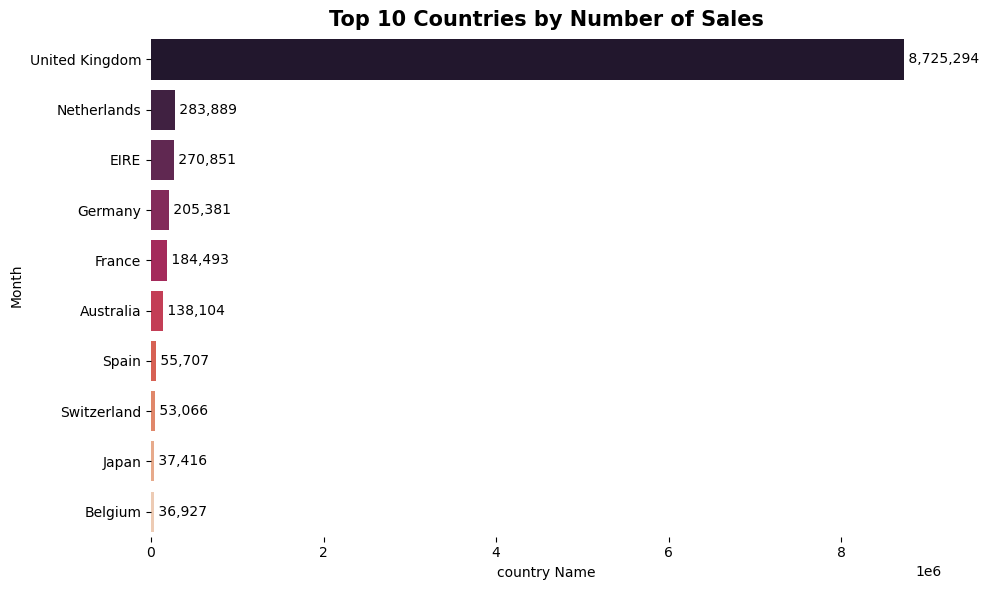

In [57]:
plt.figure(figsize=(10,6))


colors = sns.color_palette("rocket", len(country_hights_sale))

sns.barplot(
    y=country_hights_sale.index,
    x=country_hights_sale.values,
    palette=colors
)

plt.title("Top 10 Countries by Number of Sales", fontsize=15, weight="bold")
plt.xlabel("country Name")
plt.ylabel("Month")

for i, v in enumerate(country_hights_sale.values):
    plt.text(v, i, f" {v:,.0f}", va='center')

sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

It is very clear that the sales are largely dominated by UK country and cannot be compared to the others. We can focus on it and disregard the rest of the countries if needed.

Q6 Which countries placed the highest number of orders?

In [58]:
hight_order_number = (
    data_raw_analysis
    .groupby('country')['invoice_no']
    .nunique()
    .sort_values(ascending=False)
    .nlargest(10)
    )
hight_order_number

country
United Kingdom    17912
Germany             443
France              382
EIRE                282
Belgium              98
Netherlands          93
Spain                88
Australia            56
Switzerland          50
Portugal             50
Name: invoice_no, dtype: int64

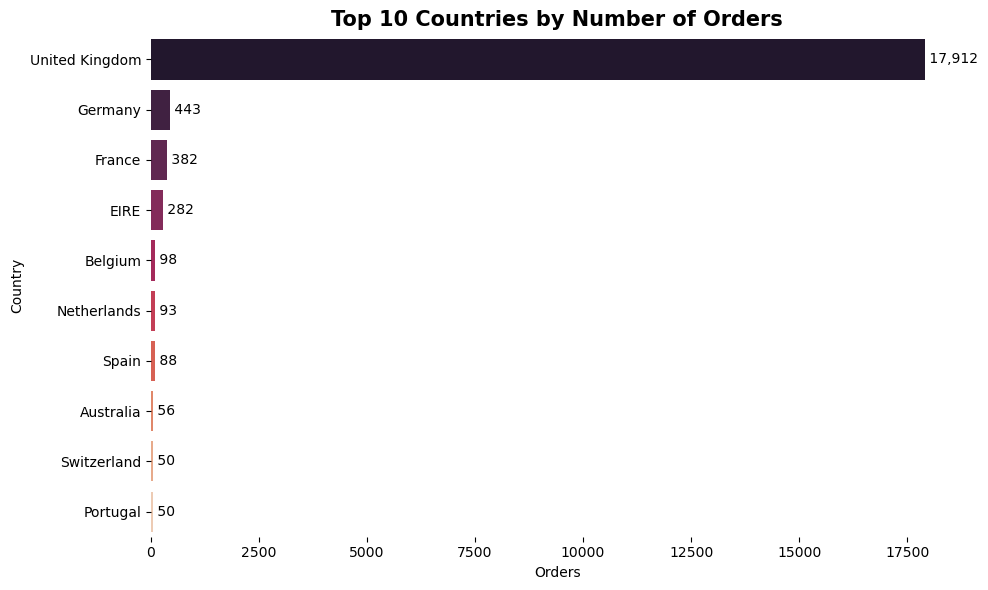

In [59]:
plt.figure(figsize=(10,6))


colors = sns.color_palette("rocket", len(hight_order_number))

sns.barplot(
    y=hight_order_number.index,
    x=hight_order_number.values,
    palette=colors
)

plt.title("Top 10 Countries by Number of Orders", fontsize=15, weight="bold")
plt.xlabel("Orders")
plt.ylabel("Country")

for i, v in enumerate(hight_order_number.values):
    plt.text(v, i, f" {v:,.0f}", va='center')

sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

Continuing, the large sales volume is mainly due to very large and high-value orders.

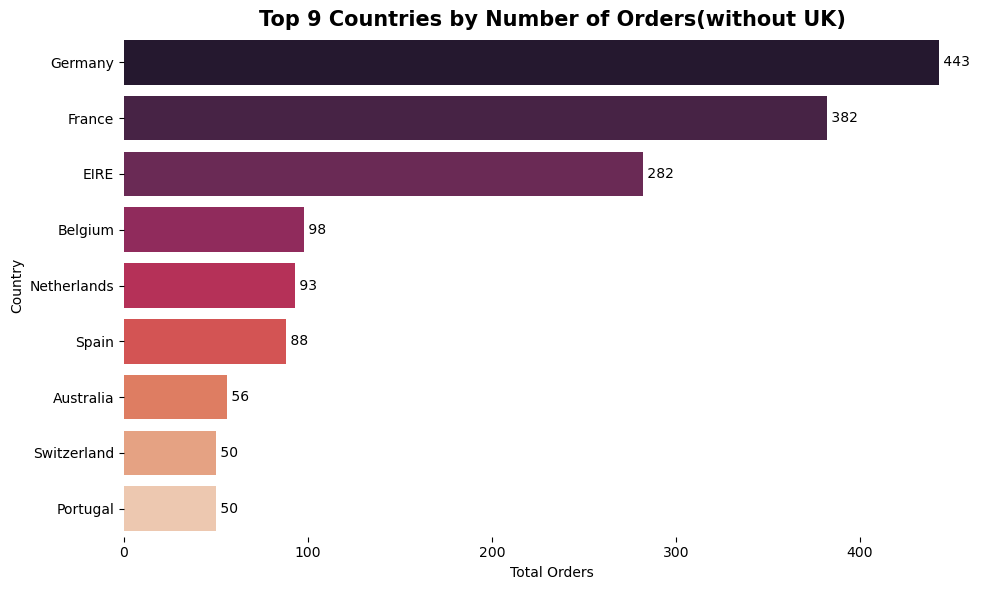

In [60]:
hight_order_number = (
    data_raw_analysis
    .groupby('country')['invoice_no']
    .nunique()
    .sort_values(ascending=False)
    .nlargest(10)
    )[1:]
hight_order_number

plt.figure(figsize=(10,6))


colors = sns.color_palette("rocket", len(hight_order_number))

sns.barplot(
    y=hight_order_number.index,
    x=hight_order_number.values,
    palette=colors
)

plt.title("Top 9 Countries by Number of Orders(without UK)", fontsize=15, weight="bold")
plt.xlabel("Total Orders")
plt.ylabel("Country")

for i, v in enumerate(hight_order_number.values):
    plt.text(v, i, f" {v:,.0f}", va='center')

sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

Here we have the orders for each country excluding the United States. It can be said that they are very weak, as the number of orders per country is less than 1,000, which is a very low figure.

Q7 Which products generated the highest sales?

In [61]:
product_with_hight_sales =(
     data_raw_analysis
     .groupby(['stock_code' , 'description'] , as_index = False)['total_sale']
     .sum()
     .round(1)
     .sort_values(by = 'total_sale' , ascending=False)
     ).head(10)
product_with_hight_sales

,stock_code,description,total_sale
1340,22423,REGENCY CAKESTAND 3 TIER,"174,156.50"
2668,23843,"PAPER CRAFT , LITTLE BIRDIE","168,469.60"
3640,85123A,WHITE HANGING HEART T-LIGHT HOLDER,"104,284.20"
2877,47566,PARTY BUNTING,"99,445.20"
3619,85099B,JUMBO BAG RED RETROSPOT,"94,159.80"
2123,23166,MEDIUM CERAMIC TOP STORAGE JAR,"81,700.90"
2029,23084,RABBIT NIGHT LIGHT,"66,870.00"
1022,22086,PAPER CHAIN KIT 50'S CHRISTMAS,"64,875.60"
3416,84879,ASSORTED COLOUR BIRD ORNAMENT,"58,927.60"
3059,79321,CHILLI LIGHTS,"54,096.40"


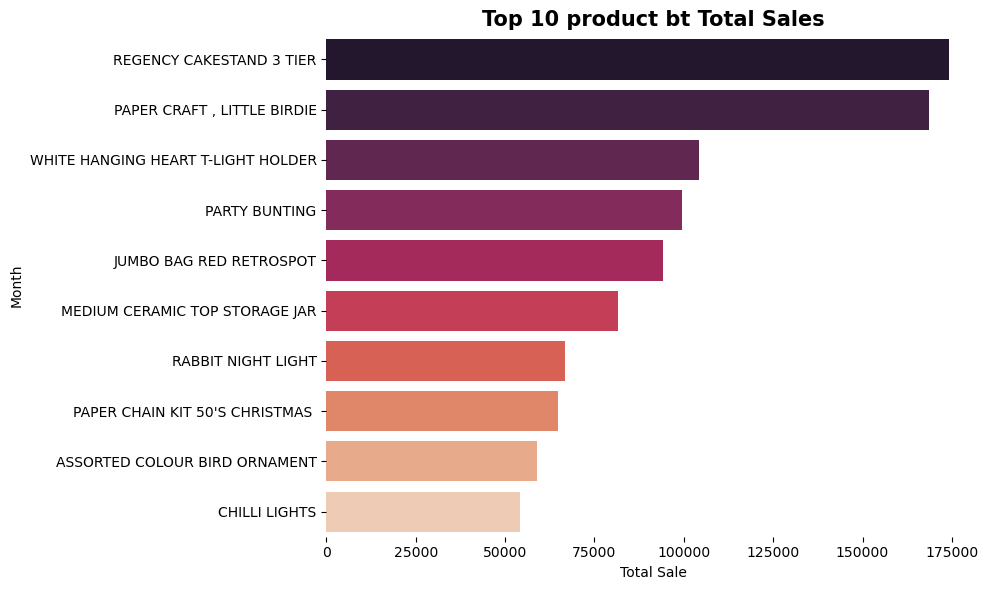

In [62]:
plt.figure(figsize=(10,6))


colors = sns.color_palette("rocket", len(product_with_hight_sales))

sns.barplot(
    x=product_with_hight_sales['total_sale'],
    y=product_with_hight_sales['description'],
    palette=colors
)

plt.title("Top 10 product bt Total Sales", fontsize=15, weight="bold")
plt.xlabel("Total Sale")
plt.ylabel("Month")

sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

The products['REGENCY CAKESTAND 3 TIER', 'PAPER CRAFT , LITTLE BIRDIE'] generate very high sales compared to others, while the lowest-selling product among the top 10 still make 50,000 in sales.

Q8 Which products generated the lowest sales?

In [63]:
product_with_lowest_sales =(
     data_raw_analysis
     .groupby(['stock_code' , 'description'] , as_index = False)['total_sale']
     .sum()
     .round(1)
     .sort_values(by = 'total_sale' , ascending=True)
     ).head(10)
product_with_lowest_sales

,stock_code,description,total_sale
4147,PADS,PADS TO MATCH ALL CUSHIONS,0.00
3142,84227,HEN HOUSE W CHICK IN NEST,0.40
2357,23366,SET 12 COLOURING PENCILS DOILEY,0.60
2921,51014c,"FEATHER PEN,COAL BLACK",0.80
3905,90084,PINK CRYSTAL GUITAR PHONE CHARM,0.80
487,21268,VINTAGE BLUE TINSEL REEL,0.80
3135,84201C,HAPPY BIRTHDAY CARD TEDDY/CAKE,1.00
3137,84206B,CAT WITH SUNGLASSES BLANK CARD,1.00
3499,84990,60 GOLD AND SILVER FAIRY CAKE CASES,1.10
2363,23370,SET 36 COLOURING PENCILS DOILEY,1.20


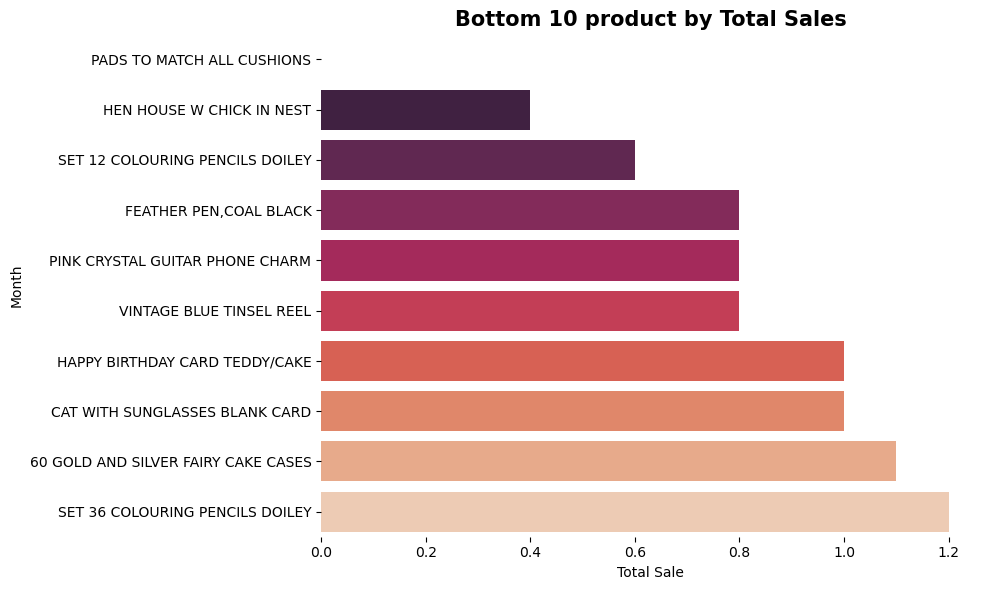

In [64]:
plt.figure(figsize=(10,6))


colors = sns.color_palette("rocket", len(product_with_lowest_sales))

sns.barplot(
    x=product_with_lowest_sales['total_sale'],
    y=product_with_lowest_sales['description'],
    palette=colors
)

plt.title("Bottom 10 product by Total Sales", fontsize=15, weight="bold")
plt.xlabel("Total Sale")
plt.ylabel("Month")

sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

Q9 Which products received the highest number of orders

In [65]:
product_with_hight_orders =( 
    data_raw_analysis
    .groupby(['stock_code' , 'description'] , as_index = False)['invoice_no']
    .nunique()
    .sort_values(by = 'invoice_no' , ascending=False)
     ).head(10)
product_with_hight_orders

,stock_code,description,invoice_no
3640,85123A,WHITE HANGING HEART T-LIGHT HOLDER,2189
3619,85099B,JUMBO BAG RED RETROSPOT,2089
1340,22423,REGENCY CAKESTAND 3 TIER,1988
2877,47566,PARTY BUNTING,1685
179,20725,LUNCH BAG RED RETROSPOT,1564
3416,84879,ASSORTED COLOUR BIRD ORNAMENT,1455
1630,22720,SET OF 3 CAKE TINS PANTRY DESIGN,1385
448,21212,PACK OF 72 RETROSPOT CAKE CASES,1320
182,20727,LUNCH BAG BLACK SKULL.,1273
1373,22457,NATURAL SLATE HEART CHALKBOARD,1249


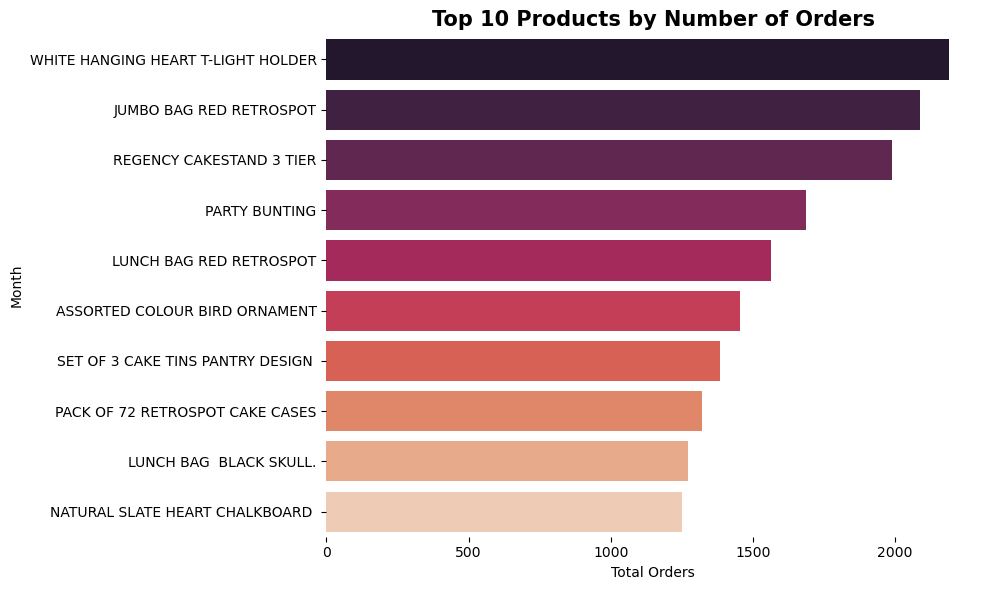

In [66]:
plt.figure(figsize=(10,6))


colors = sns.color_palette("rocket", len(product_with_hight_orders))

sns.barplot(
    x=product_with_hight_orders['invoice_no'],
    y=product_with_hight_orders['description'],
    palette=colors
)

plt.title("Top 10 Products by Number of Orders", fontsize=15, weight="bold")
plt.xlabel("Total Orders")
plt.ylabel("Month")

sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

Some products with the highest sales appear repeatedly, while there are also new products, indicating a diversity in the products being purchased.

## Key Business Insights



It can be concluded that months 11, 9, and 10 are the months with the highest product demand, so it is important to ensure that all products are available and stocked for a short period. Additionally, month 1 shows a high average total sales value, suggesting opportunities to implement strategies to further increase total sales and profitability. Month 4 has the lowest number of sales and orders, so targeted improvements, promotions, or brochures could be used to attract more customers and boost purchases during this month.

It can be observed that the Afternoon period, especially on Tuesday and Thursday, represents the busiest time in terms of customer activity. Therefore, discounts could be offered during less busy periods to help balance demand.
Additionally, attention should be given to ensuring sufficient product availability and inventory during peak days and high-demand time periods in order to maintain customer satisfaction.


Country-Level Sales Insights

Regarding sales and total orders by country, it is clear that the United Kingdom outperforms all other countries. Therefore, management could consider either focusing solely on the UK market to maximize profitability in a specific region or implementing targeted promotions and recommendations for other international markets. Alternatively, attention could be given to the top three external markets after the UK, aiming to increase sales, boost orders, and improve overall profitability.

There is diversity among the top-selling and most-ordered products. This variation in both sales and order volume indicates that we can focus on the best-selling products and ensure they are always available to maximize presence and increase profitability.

## Future Actions / Recommendations


Future actions could include investigating the reasons behind low-sales months, such as month 4, and implementing strategies to improve sales. Additionally, analyzing the best-selling and most-ordered products during peak months can help increase stock availability in warehouses and ensure these products are maintained during periods of high demand.

Advertising campaigns and profit-boosting initiatives can be gradually directed, with a focus on the local market to increase sales and revenue for products, regardless of competitive pricing.

